# 03 — LSTM Comparator: Price Levels vs Fractional Differencing

A controlled experiment. Everything is held fixed — architecture, seed, lookback,
training window, evaluation — and **only the input representation changes**:

| Arm | Input to the LSTM |
|---|---|
| **A — levels** | Monthly average price, exactly as-is |
| **B — returns** | `d = 1`, log returns (what ARIMA's differencing does) |
| **C — fracdiff** | `d` chosen per stock as the minimum passing order |

The scaffolding follows the
[Stock-Portfolio-Optimiser](https://github.com/lakshya-aga/Stock-Portfolio-Optimiser)
project: monthly-average prices, a fixed train/test date split, **recursive**
multi-step forecasting where each prediction is fed back in, then a Roy-ratio
allocation scored against equal-weight controls. The only substitution is LSTM
where that project used ARIMA.

## Why the arms should differ

An LSTM on raw price levels has a specific failure mode. The series has a unit root,
so the lowest-loss solution reachable by gradient descent is usually
"predict approximately the last value". That produces a forecast that looks excellent
on a chart — it tracks the actual line closely — and is worthless, because it is a
lagged copy carrying no directional information. RMSE rewards it; directional accuracy
exposes it, which is why both are reported below.

Differencing to `d=1` removes the unit root but discards the level entirely. Fractional
`d` is the middle: stationary enough to learn from, with most of the memory intact.

**Comparability.** Arms B and C train in differenced space, so their forecasts are
inverted back to prices before any metric is computed.
`FracDiffTransformer.invert_next` does this exactly — the FFD lead weight is 1.0 and
every lagged term is known, so nothing is approximated.

In [1]:
import logging, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from afml_india.research import Snapshot, find_snapshot, fracdiff_scan, min_ffd_order
from afml_india.models.forecast import (
    FracDiffTransformer, ForecastConfig,
    recursive_forecast_levels, forecast_errors,
)
from afml_india.portfolio import (
    roy_allocation, equal_weights, compare_portfolios, control_portfolios,
    performance_summary, project_sharpe, annualised_sharpe, default_cost_model,
)

warnings.filterwarnings("ignore")
logging.getLogger("afml_india").setLevel(logging.WARNING)
pd.set_option("display.width", 130, "display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
SEED = 0

## 1. Monthly-average prices from the point-in-time universe

The original project used monthly means of daily closes. Same here, but the universe
is the **point-in-time** NIFTY membership from the snapshot's as-of date rather than
today's list — so the experiment is not handed a set of names pre-selected for having
survived.

In [2]:
snap = Snapshot(find_snapshot())
print(snap)
if snap.is_synthetic:
    print("\n*** SYNTHETIC DATA — the comparison is mechanically valid, but any")
    print("    conclusion about which arm wins requires real prices. ***\n")

daily = snap.daily_panel("px_last")
monthly = daily.resample("ME").mean().dropna(how="all").ffill().dropna()

print(f"{monthly.shape[1]} stocks x {len(monthly)} months")
print(f"{monthly.index[0]:%Y-%m}  ->  {monthly.index[-1]:%Y-%m}")
monthly.tail(3).round(2)

Snapshot(nifty_index_20160822.zip SYNTHETIC, index=NIFTY Index, as_of=2016-08-22, members=5)

*** SYNTHETIC DATA — the comparison is mechanically valid, but any
    conclusion about which arm wins requires real prices. ***

5 stocks x 121 months
2016-08  ->  2026-08


,HDFCB_IN,ICICIBC_IN,INFO_IN,RIL_IN,TCS_IN
date,,,,,
2026-06-30,4104.05,424.91,4681.24,843.24,5658.59
2026-07-31,4731.11,440.57,4545.39,935.61,5813.90
2026-08-31,5115.77,437.46,4380.61,922.08,6483.71


In [3]:
# Fixed chronological split, in the spirit of the original's 2010-2017 / 2018-2022.
split_at = monthly.index[int(len(monthly) * 0.75)]
train_months = (monthly.index <= split_at).sum()
test_months = (monthly.index > split_at).sum()

print(f"Train: {monthly.index[0]:%Y-%m} to {split_at:%Y-%m}  ({train_months} months)")
print(f"Test : {monthly.index[monthly.index > split_at][0]:%Y-%m} to "
      f"{monthly.index[-1]:%Y-%m}  ({test_months} months)")
print(f"\nThe test arm forecasts {test_months} steps recursively, never seeing a realised price.")

Train: 2016-08 to 2024-02  (91 months)
Test : 2024-03 to 2026-08  (30 months)

The test arm forecasts 30 steps recursively, never seeing a realised price.


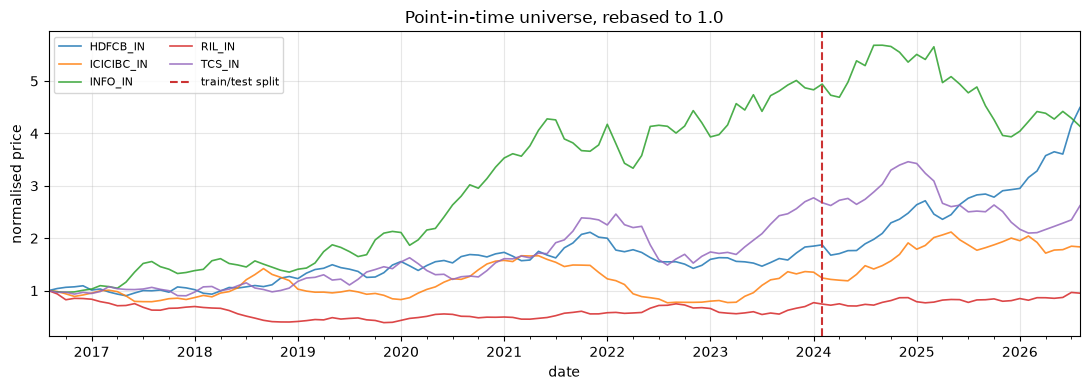

In [4]:
normalised = monthly / monthly.iloc[0]
fig, ax = plt.subplots()
normalised.plot(ax=ax, lw=1.2, alpha=0.85)
ax.axvline(split_at, c="#c33", ls="--", lw=1.5, label="train/test split")
ax.set_title("Point-in-time universe, rebased to 1.0")
ax.set_ylabel("normalised price"); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 2. Choose `d` per stock

The differencing order is a per-series property, not a global constant. Scanning each
stock separately is the whole point of the fracdiff arm — pinning one `d` across the
universe would give some names too much differencing and others too little.

In [5]:
rows = []
for symbol in monthly.columns:
    train_series = monthly.loc[monthly.index <= split_at, symbol]
    try:
        best = min_ffd_order(train_series, thresh=1e-3, max_order=1.0, step=0.05, min_obs=40)
        rows.append({"symbol": symbol, "d": best["d"], "adf_p": best["adf_pvalue"],
                     "memory": best["corr"], "n_obs": best["n_obs"]})
    except ValueError as exc:
        print(f"{symbol}: {exc}")
        rows.append({"symbol": symbol, "d": 1.0, "adf_p": np.nan, "memory": np.nan, "n_obs": np.nan})

orders = pd.DataFrame(rows).set_index("symbol")
print("Selected on the TRAINING window only — choosing d on the full series would leak.")
orders.round(4)

Selected on the TRAINING window only — choosing d on the full series would leak.


,d,adf_p,memory,n_obs
symbol,,,,
HDFCB_IN,0.50,0.0350,0.6766,46
ICICIBC_IN,0.85,0.0338,0.2632,75
INFO_IN,0.45,0.0010,0.3202,41
RIL_IN,0.55,0.0216,0.6661,51
TCS_IN,0.65,0.0411,0.5283,60


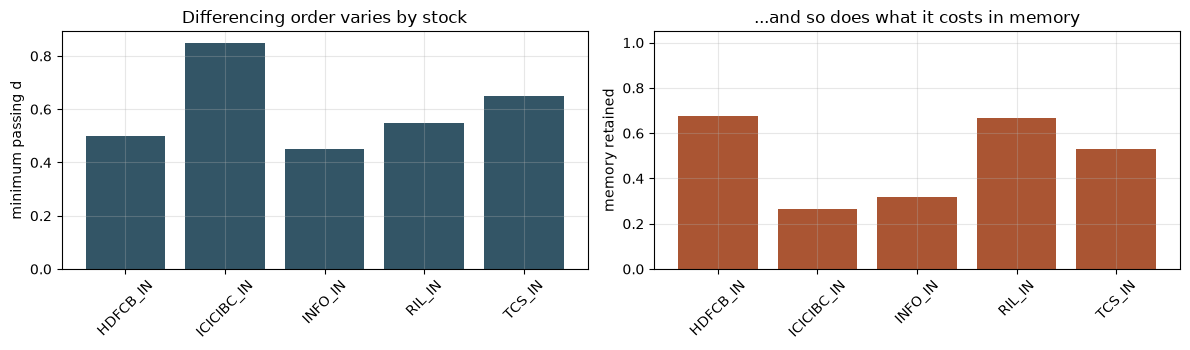

Mean d across the universe        : 0.60
Mean memory retained at that d    : 49.1%
Memory retained at d=1.0 (returns): typically under 5%


In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.bar(orders.index, orders["d"], color="#356")
a1.set_ylabel("minimum passing d"); a1.set_title("Differencing order varies by stock")
a1.tick_params(axis="x", rotation=45)
a2.bar(orders.index, orders["memory"], color="#a53")
a2.set_ylabel("memory retained"); a2.set_ylim(0, 1.05)
a2.set_title("...and so does what it costs in memory")
a2.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print(f"Mean d across the universe        : {orders['d'].mean():.2f}")
print(f"Mean memory retained at that d    : {orders['memory'].mean():.1%}")
print(f"Memory retained at d=1.0 (returns): typically under 5%")

## 3. Run all three arms

Identical `ForecastConfig` throughout — same architecture, same seed, same early
stopping. Any difference in the results is attributable to the input representation
and nothing else.

In [7]:
FORECAST_CONFIG = ForecastConfig(
    lookback=12, hidden_size=32, num_layers=2, dropout=0.1,
    learning_rate=5e-3, max_epochs=300, patience=40, seed=SEED,
)

def run_arm(symbol, arm):
    """Recursive forecast for one stock under one input representation."""
    series = monthly[symbol]
    if arm == "levels":
        transformer = None
    elif arm == "returns":
        transformer = FracDiffTransformer(d=1.0, thresh=1e-3, log=True)
    elif arm == "fracdiff":
        transformer = FracDiffTransformer(d=float(orders.loc[symbol, "d"]), thresh=1e-3, log=True)
    else:
        raise ValueError(arm)
    return recursive_forecast_levels(
        series, train_end=split_at, config=FORECAST_CONFIG, transformer=transformer
    )

ARMS = ["levels", "returns", "fracdiff"]
forecasts = {arm: {} for arm in ARMS}

for arm in ARMS:
    for symbol in monthly.columns:
        try:
            forecasts[arm][symbol] = run_arm(symbol, arm)
        except Exception as exc:
            print(f"  {arm}/{symbol} failed: {exc}")
    print(f"{arm:>9}: {len(forecasts[arm])}/{len(monthly.columns)} stocks forecast")

   levels: 5/5 stocks forecast


  returns: 5/5 stocks forecast


 fracdiff: 5/5 stocks forecast


## 4. Forecast accuracy

Read **directional accuracy** first, not RMSE.

A naive "repeat the last value" forecast scores a flattering RMSE on a trending
series while getting direction right only by chance. RMSE measures how close the
level is; directional accuracy measures whether the model knows which way the series
is going. Only the second is tradeable.

In [8]:
actual = monthly[monthly.index > split_at]

error_rows = []
for arm in ARMS:
    for symbol, forecast in forecasts[arm].items():
        errors = forecast_errors(actual[symbol], forecast)
        errors["arm"], errors["symbol"] = arm, symbol
        error_rows.append(errors)

errors_df = pd.DataFrame(error_rows)
by_arm = errors_df.groupby("arm")[
    ["rmse", "mae", "mape", "bias", "directional_accuracy"]
].mean().loc[ARMS]
by_arm.round(4)

,rmse,mae,mape,bias,directional_accuracy
arm,,,,,
levels,801.3511,652.4865,24.1418,-545.8000,0.4690
returns,1160.1346,926.6893,31.8892,426.4483,0.5517
fracdiff,999.0111,794.5798,27.6420,-422.4418,0.3793


In [9]:
# The naive benchmark every level model must beat: carry the last training price forward.
naive_rows = []
for symbol in monthly.columns:
    last = float(monthly.loc[monthly.index <= split_at, symbol].iloc[-1])
    flat = pd.Series(last, index=actual.index)
    e = forecast_errors(actual[symbol], flat)
    e["symbol"] = symbol
    naive_rows.append(e)
naive = pd.DataFrame(naive_rows)

comparison = by_arm.copy()
comparison.loc["naive_last_value"] = naive[
    ["rmse", "mae", "mape", "bias", "directional_accuracy"]
].mean()
print("Mean across stocks (lower error better; directional accuracy above 0.5 better):")
comparison.round(4)

Mean across stocks (lower error better; directional accuracy above 0.5 better):


,rmse,mae,mape,bias,directional_accuracy
arm,,,,,
levels,801.3511,652.4865,24.1418,-545.8000,0.4690
returns,1160.1346,926.6893,31.8892,426.4483,0.5517
fracdiff,999.0111,794.5798,27.6420,-422.4418,0.3793
naive_last_value,609.1713,497.8172,17.5190,-202.8225,0.0000


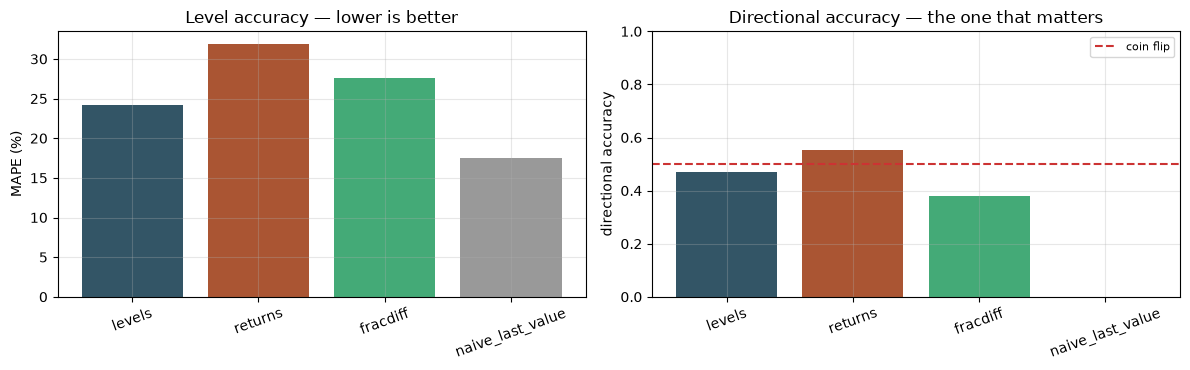

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
order = [*ARMS, "naive_last_value"]
colours = ["#356", "#a53", "#4a7", "#999"]

a1.bar(order, comparison.loc[order, "mape"], color=colours)
a1.set_ylabel("MAPE (%)"); a1.set_title("Level accuracy — lower is better")
a1.tick_params(axis="x", rotation=20)

a2.bar(order, comparison.loc[order, "directional_accuracy"], color=colours)
a2.axhline(0.5, c="#c33", ls="--", lw=1.5, label="coin flip")
a2.set_ylabel("directional accuracy"); a2.set_ylim(0, 1)
a2.set_title("Directional accuracy — the one that matters")
a2.tick_params(axis="x", rotation=20); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [11]:
# Per-stock detail: is any arm consistently ahead, or is it noise across names?
pivot = errors_df.pivot(index="symbol", columns="arm", values="directional_accuracy")[ARMS]
print("Directional accuracy by stock:")
print(pivot.round(3).to_string())
print("\nArm with the best directional accuracy, per stock:")
print(pivot.idxmax(axis=1).value_counts().to_string())

Directional accuracy by stock:
arm         levels  returns  fracdiff
symbol                               
HDFCB_IN     0.483    0.828     0.310
ICICIBC_IN   0.483    0.379     0.379
INFO_IN      0.552    0.414     0.414
RIL_IN       0.586    0.552     0.483
TCS_IN       0.241    0.586     0.310

Arm with the best directional accuracy, per stock:
levels     3
returns    2


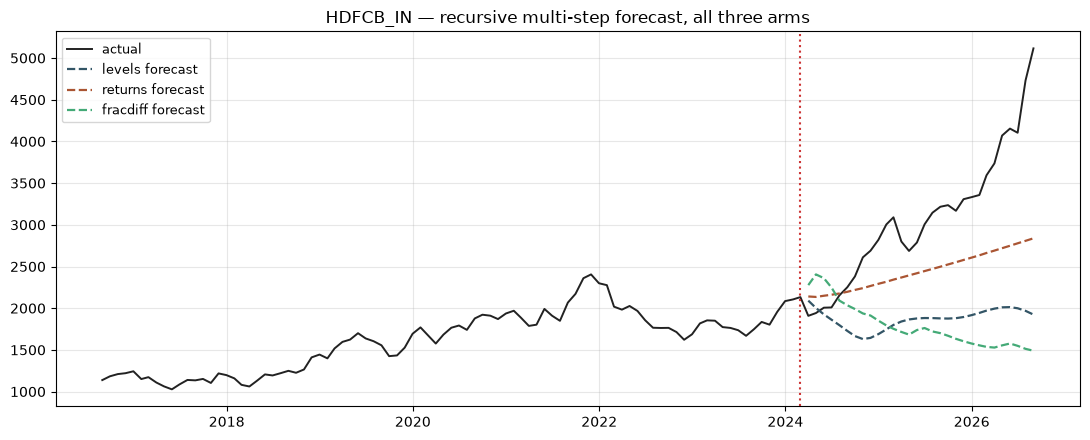

Recursive forecasts drift: each step consumes the previous prediction, so error
compounds. A one-step-ahead chart would look far tighter and mean far less.


In [12]:
symbol = monthly.columns[0]
fig, ax = plt.subplots(figsize=(11, 4.5))
history = monthly[symbol]
ax.plot(history.index, history.to_numpy(), color="#222", lw=1.4, label="actual")
for arm, colour in zip(ARMS, ["#356", "#a53", "#4a7"]):
    if symbol in forecasts[arm]:
        f = forecasts[arm][symbol]
        ax.plot(f.index, f.to_numpy(), lw=1.6, ls="--", color=colour, label=f"{arm} forecast")
ax.axvline(split_at, c="#c33", ls=":", lw=1.5)
ax.set_title(f"{symbol} — recursive multi-step forecast, all three arms")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Recursive forecasts drift: each step consumes the previous prediction, so error")
print("compounds. A one-step-ahead chart would look far tighter and mean far less.")

## 5. Does the forecast survive contact with a portfolio?

Forecast error is a proxy. What the original project actually cared about is whether
a Roy-ratio allocation built on the forecasts beats equal weight. This is a much
harder test, and the place where most forecasting results quietly die.

The Roy ratio is expected rise divided by the spread of the forecast path — a crude
risk adjustment where the forecast's own dispersion stands in for uncertainty.

In [13]:
last_train_prices = monthly.loc[monthly.index <= split_at].iloc[-1]
test_prices = monthly[monthly.index > split_at]

allocations = {}
for arm in ARMS:
    if forecasts[arm]:
        allocations[f"roy_{arm}"] = roy_allocation(forecasts[arm], last_train_prices)
allocations["equal_weight"] = equal_weights(test_prices.columns)

weights_frame = pd.DataFrame(allocations).round(4)
print("Portfolio weights:")
weights_frame

2026-08-22 12:45:22 | WARNING | afml_india.portfolio | All Roy ratios are non-positive; falling back to equal weight


Portfolio weights:


,roy_levels,roy_returns,roy_fracdiff,equal_weight
HDFCB_IN,0.2,0.3284,0.0,0.2
ICICIBC_IN,0.2,0.0000,0.0,0.2
INFO_IN,0.2,0.3399,1.0,0.2
RIL_IN,0.2,0.0000,0.0,0.2
TCS_IN,0.2,0.3317,0.0,0.2


In [14]:
values, summary = compare_portfolios(test_prices, allocations, periods_per_year=12)
print("Buy and hold over the test window (no rebalancing):")
summary.round(4)

Buy and hold over the test window (no rebalancing):


,total_return,cagr,volatility,sharpe,project_sharpe,max_drawdown,periods
roy_levels,0.4764,0.1749,0.0876,1.1518,2.9421,-0.0715,29.0
roy_returns,0.5088,0.1855,0.1215,0.9348,2.2839,-0.1510,29.0
roy_fracdiff,-0.1253,-0.0539,0.1615,-0.6660,-0.4103,-0.3075,29.0
equal_weight,0.4764,0.1749,0.0876,1.1518,2.9421,-0.0715,29.0


In [15]:
values_rb, summary_rb = compare_portfolios(
    test_prices, allocations, rebalance=True,
    cost_model=default_cost_model(), periods_per_year=12,
)
print("Monthly rebalanced, with Indian delivery costs charged on turnover:")
summary_rb.round(4)

Monthly rebalanced, with Indian delivery costs charged on turnover:


,total_return,cagr,volatility,sharpe,project_sharpe,max_drawdown,periods
roy_levels,0.4000,0.1494,0.0859,0.9144,2.5958,-0.0957,29.0
roy_returns,0.3484,0.1317,0.1153,0.5711,1.7628,-0.1896,29.0
roy_fracdiff,-0.1253,-0.0539,0.1615,-0.6660,-0.4103,-0.3075,29.0
equal_weight,0.4000,0.1494,0.0859,0.9144,2.5958,-0.0957,29.0


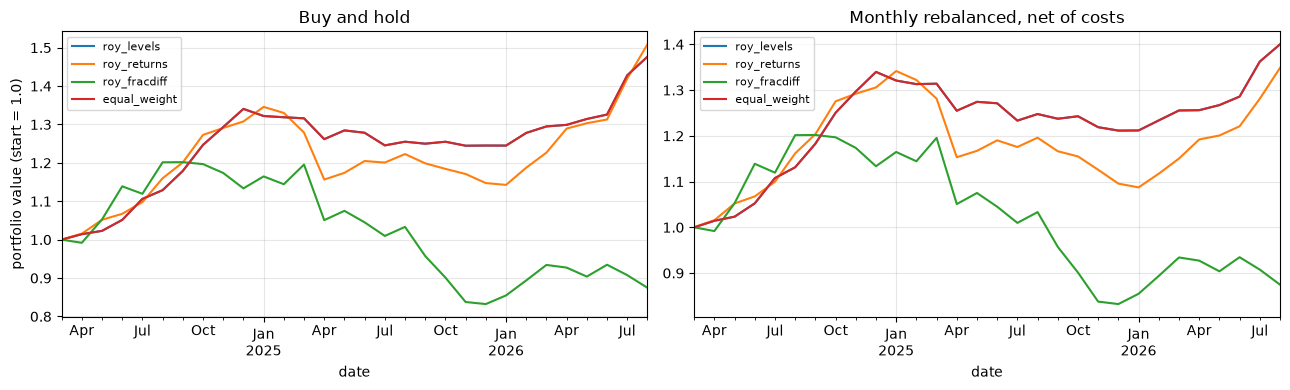

In [16]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
values.plot(ax=a1, lw=1.5)
a1.set_title("Buy and hold"); a1.set_ylabel("portfolio value (start = 1.0)")
a1.legend(fontsize=8)
values_rb.plot(ax=a2, lw=1.5)
a2.set_title("Monthly rebalanced, net of costs"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [17]:
best_total = summary["total_return"].idxmax()
best_sharpe = summary["sharpe"].idxmax()
equal_total = summary.loc["equal_weight", "total_return"]

print(f"Best total return : {best_total} ({summary.loc[best_total, 'total_return']:.2%})")
print(f"Best Sharpe       : {best_sharpe} ({summary.loc[best_sharpe, 'sharpe']:.2f})")
print(f"Equal-weight hold : {equal_total:.2%}")
print()
beat = summary[summary["total_return"] > equal_total].index.tolist()
beat = [b for b in beat if b != "equal_weight"]
if beat:
    print(f"Beat the equal-weight control: {', '.join(beat)}")
else:
    print("No forecast-driven allocation beat equal weight.")
    print("On a small universe over a short window that is the expected outcome, and it")
    print("is worth taking seriously: equal weight is a strong benchmark precisely")
    print("because it makes no forecast that can be wrong.")

Best total return : roy_returns (50.88%)
Best Sharpe       : roy_levels (1.15)
Equal-weight hold : 47.64%

Beat the equal-weight control: roy_returns


## 6. What actually changed

The point of the experiment is the delta between arms, so state it explicitly rather
than leaving it to be read off a chart.

In [18]:
delta = pd.DataFrame({
    "mape": comparison.loc[ARMS, "mape"],
    "directional_accuracy": comparison.loc[ARMS, "directional_accuracy"],
    "portfolio_total_return": [
        summary.loc[f"roy_{arm}", "total_return"] if f"roy_{arm}" in summary.index else np.nan
        for arm in ARMS
    ],
    "portfolio_sharpe": [
        summary.loc[f"roy_{arm}", "sharpe"] if f"roy_{arm}" in summary.index else np.nan
        for arm in ARMS
    ],
    "mean_d": [0.0, 1.0, orders["d"].mean()],
    "mean_memory_retained": [1.0, np.nan, orders["memory"].mean()],
})
delta.round(4)

,mape,directional_accuracy,portfolio_total_return,portfolio_sharpe,mean_d,mean_memory_retained
arm,,,,,,
levels,24.1418,0.4690,0.4764,1.1518,0.0,1.0000
returns,31.8892,0.5517,0.5088,0.9348,1.0,NaN
fracdiff,27.6420,0.3793,-0.1253,-0.6660,0.6,0.4909


In [19]:
levels_da = comparison.loc["levels", "directional_accuracy"]
returns_da = comparison.loc["returns", "directional_accuracy"]
frac_da = comparison.loc["fracdiff", "directional_accuracy"]

print("Directional accuracy")
print(f"  levels   : {levels_da:.3f}")
print(f"  returns  : {returns_da:.3f}   ({returns_da - levels_da:+.3f} vs levels)")
print(f"  fracdiff : {frac_da:.3f}   ({frac_da - levels_da:+.3f} vs levels)")
print()
print("Level error (MAPE, lower better)")
for arm in ARMS:
    print(f"  {arm:>8} : {comparison.loc[arm, 'mape']:.2f}%")
print()
n_stocks, n_months = len(monthly.columns), test_months
print(f"Caveat on sample size: {n_stocks} stocks x {n_months} test months. The standard")
print(f"error on a directional-accuracy estimate from {n_months} steps is roughly")
print(f"{0.5 / np.sqrt(n_months):.3f}, so differences smaller than about")
print(f"{2 * 0.5 / np.sqrt(n_months):.2f} are not distinguishable from noise here.")

Directional accuracy
  levels   : 0.469
  returns  : 0.552   (+0.083 vs levels)
  fracdiff : 0.379   (-0.090 vs levels)

Level error (MAPE, lower better)
    levels : 24.14%
   returns : 31.89%
  fracdiff : 27.64%

Caveat on sample size: 5 stocks x 30 test months. The standard
error on a directional-accuracy estimate from 30 steps is roughly
0.091, so differences smaller than about
0.18 are not distinguishable from noise here.


## Takeaways

1. **Always report directional accuracy.** An LSTM on price levels can post a
   respectable RMSE purely by learning to echo the last value. RMSE will not tell you;
   directional accuracy and the naive-last-value benchmark will.

2. **Fractional differencing is the middle path, and it has to be chosen per series.**
   `d` varies across the universe, and so does what it costs in memory. A single global
   `d` over- or under-differences most of the names.

3. **The fracdiff arm is scored fairly.** Its forecasts are inverted exactly back to
   price space before any metric is computed, so the comparison is like for like.

4. **Recursive multi-step forecasting is hard, and honest.** Error compounds because
   every step consumes the model's own previous output. Charts that show one-step-ahead
   predictions against actuals are showing a much easier problem.

5. **Equal weight is a serious benchmark.** A forecast-driven allocation that does not
   clear it has not earned its complexity — and once Indian delivery costs are charged
   on rebalancing turnover, the bar rises again.

### Next steps for this experiment

- Rerun against real Bloomberg data; every number above is from synthetic prices.
- Widen the universe to the full point-in-time NIFTY membership.
- Add a walk-forward version: refit each year rather than once, so the model sees
  regime change.
- Try classification rather than level forecasting — that is notebook **04**, which
  uses triple-barrier labels and purged CV instead of RMSE.